In [35]:
import os
import sys
import json
import cv2
import matplotlib.pyplot as plt


In [36]:
sys.path.append(os.path.abspath(os.path.join("..")))


In [37]:
from src.preprocessing import (
    resize_image, remove_noise, normalize_lighting,
    preprocess_image, get_sample_filenames, batch_preprocess
)

In [38]:
RAW_DIR = "../data/raw"
TRAIN_DIR = os.path.join(RAW_DIR, "train2019")
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [39]:
sample_filenames = get_sample_filenames(TRAIN_DIR, limit=20)
sample_path = os.path.join(TRAIN_DIR, sample_filenames[0])

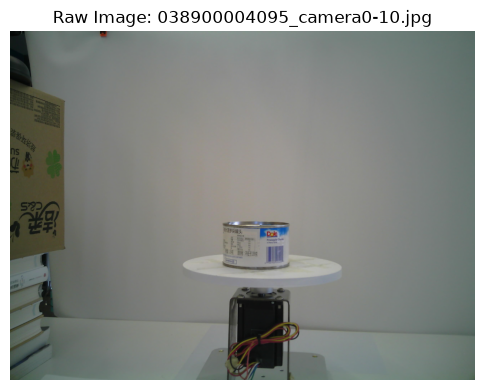

In [40]:
img = cv2.imread(sample_path)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Raw Image: {sample_filenames[0]}")
plt.axis("off")
plt.show()

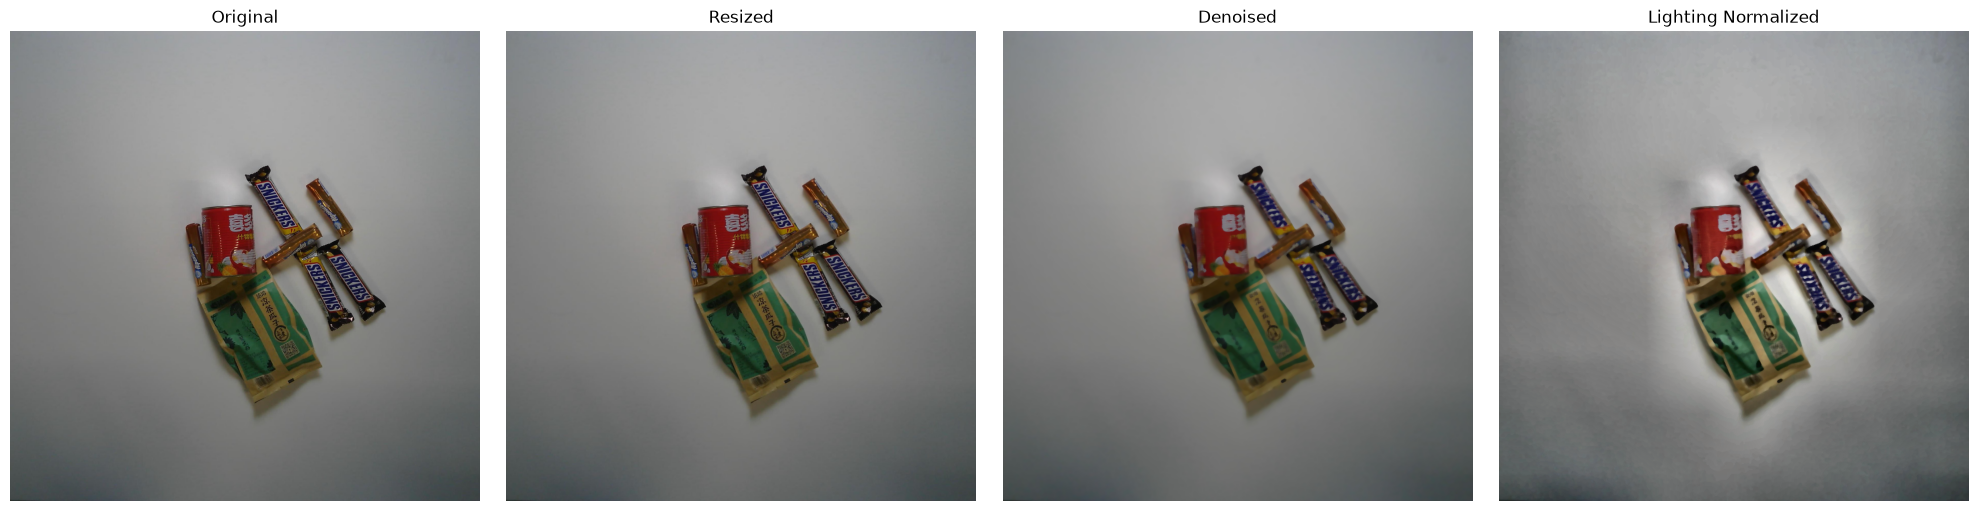

In [48]:
resized = resize_image(img)
denoised = remove_noise(resized, method="median")
normalized = normalize_lighting(denoised)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Original", "Resized", "Denoised", "Lighting Normalized"]
images = [img, resized, denoised, normalized]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [49]:
success, total = batch_preprocess(sample_filenames, TRAIN_DIR, PROCESSED_DIR)
print(f"Processed {success}/{total} images -> {PROCESSED_DIR}")

Processed 20/20 images -> ../data/processed
